# FMNIST: how does performativity affect backdoor vulnerability?

Centralized RGD on Fashion-MNIST + PerfFL's class-resampling performativity.

Poisoning: Fixed BadNets patch of size **δ x δ**, sweeping sampling temperature **α** as performativity strength.

**α = 0** is the non-performative comparison: just relabeling with no patch

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "fmnist":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import torch

from fmnist.experiment_setup import load_fmnist, make_model
from fmnist.algorithms import run_rgd, evaluate
from fmnist import backdoor
from fmnist.plotting import (
    plot_asr_over_rounds_grid,
    plot_class_mix_grid,
    plot_asr_vs_alpha,
    save_figure,
)

## Hyperparameters

In [ ]:
# data / training
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 200
N_ROUNDS = 30
LR = 0.05
EPOCHS = 1          # gradient passes per RGD round
BATCH_SIZE = 128
DEVICE = "cpu"
SEED = 0

# attack (see fmnist/backdoor.py for trigger shape / target label)
POISON_RATE = 0.02   # epsilon: fraction of training set triggered

# performativity
# ALPHAS: every alpha actually run. the ASR-vs-alpha sweep plots ALL of these.
# PLOT_ALPHAS: coarse subset shown as panels in the over-rounds grids (must be a subset of ALPHAS).
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4.0]
PLOT_ALPHAS = [0.0, 0.5, 1.0, 2.0, 4.0]
EVAL_WINDOW = 5     # rounds averaged for the sweep summary

## Load data

In [3]:
train_x, train_y, test_x, test_y = load_fmnist(
    data_root=str(root / "data"),
    train_per_class=TRAIN_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    seed=SEED,
)
print("train:", train_x.shape, "test:", test_x.shape)

train: torch.Size([5000, 1, 28, 28]) test: torch.Size([2000, 1, 28, 28])


## Run all alphas

Run clean + poisoned RGD for every alpha in `ALPHAS` 
and stores the full histories in `runs`, plus a derived
`summary_rows`. Change `PLOT_ALPHAS` or
swap plots and re-run just the plot cell, **not** this runs cell.

In [4]:
def run_pair(alpha, seed=SEED):
    """Return (clean_history, poisoned_history) for one alpha."""
    asr_fn = backdoor.make_asr_fn(test_x, test_y, device=DEVICE)
    prior_fn = backdoor.make_prior_fn(test_x, test_y, device=DEVICE)
    common = dict(
        alpha=alpha, n_rounds=N_ROUNDS, lr=LR, epochs=EPOCHS,
        batch_size=BATCH_SIZE, device=DEVICE,
    )

    # clean run (no poison)
    clean_model = make_model(seed=seed, device=DEVICE)
    clean_hist = run_rgd(clean_model, train_x, train_y, test_x, test_y,
                         asr_fn=asr_fn, **common)

    # poisoned run: each round, trigger a FRESH epsilon-fraction of the clean
    # data (per-round seed). Exactly epsilon are triggered every round, but a
    # sample poisoned this round is clean next round unless re-chosen. The
    # trigger + target label stay fixed, so the attack is still static.
    def poison_fn(x, y, t):
        return backdoor.badnets_poison(x, y, poison_rate=POISON_RATE, seed=seed + 1 + t)

    pois_model = make_model(seed=seed, device=DEVICE)
    pois_hist = run_rgd(pois_model, train_x, train_y, test_x, test_y,
                        poison_fn=poison_fn, asr_fn=asr_fn, prior_fn=prior_fn, **common)
    return clean_hist, pois_hist

In [5]:
# Note: this is the only time-consuming cell for actual runs
# runs[alpha] = (clean_hist, pois_hist)
runs = {a: run_pair(a) for a in ALPHAS}

def _tail_mean(hist, key):
    return sum(h[key] for h in hist[-EVAL_WINDOW:]) / EVAL_WINDOW

# derived summary (one row per alpha) -- no extra training
summary_rows = []
for a in ALPHAS:
    ch, ph = runs[a]
    tail_clean = _tail_mean(ch, "clean_acc")
    tail_pois = _tail_mean(ph, "clean_acc")
    tail_asr = _tail_mean(ph, "asr")
    tail_prior = _tail_mean(ph, "prior_rate")
    summary_rows.append({
        "alpha": a, "asr": tail_asr, "prior_rate": tail_prior,
        "lift": tail_asr - tail_prior,
        "clean_acc": tail_clean, "poisoned_acc": tail_pois,
    })
    print(f"alpha={a:>4}  ASR={tail_asr:.3f}  prior={tail_prior:.3f}  "
          f"lift={tail_asr - tail_prior:+.3f}  "
          f"clean_acc={tail_clean:.3f}  poisoned_acc={tail_pois:.3f}")

alpha= 0.0  ASR=0.990  prior=0.026  lift=+0.964  clean_acc=0.826  poisoned_acc=0.829
alpha=0.25  ASR=0.992  prior=0.024  lift=+0.967  clean_acc=0.828  poisoned_acc=0.832
alpha= 0.5  ASR=0.985  prior=0.019  lift=+0.966  clean_acc=0.821  poisoned_acc=0.824
alpha=0.75  ASR=0.994  prior=0.020  lift=+0.973  clean_acc=0.826  poisoned_acc=0.820
alpha= 1.0  ASR=0.981  prior=0.018  lift=+0.962  clean_acc=0.826  poisoned_acc=0.829
alpha=1.25  ASR=0.991  prior=0.017  lift=+0.974  clean_acc=0.825  poisoned_acc=0.825
alpha= 1.5  ASR=0.984  prior=0.023  lift=+0.961  clean_acc=0.830  poisoned_acc=0.809
alpha=1.75  ASR=0.961  prior=0.017  lift=+0.944  clean_acc=0.813  poisoned_acc=0.803
alpha= 2.0  ASR=0.839  prior=0.015  lift=+0.824  clean_acc=0.779  poisoned_acc=0.728
alpha= 2.5  ASR=0.533  prior=0.022  lift=+0.511  clean_acc=0.700  poisoned_acc=0.662
alpha= 3.0  ASR=0.719  prior=0.055  lift=+0.664  clean_acc=0.625  poisoned_acc=0.588
alpha= 3.5  ASR=0.609  prior=0.043  lift=+0.566  clean_acc=0.623 

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_over_rounds_grid_eps0.02_20260715_130909.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_over_rounds_grid_eps0.02_20260715_130909.png')

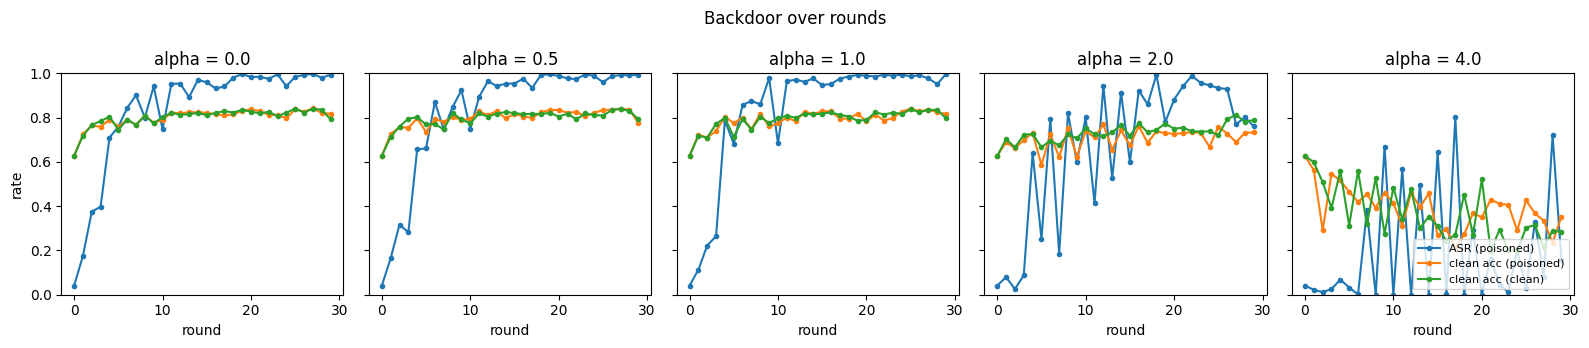

In [6]:
# Backdoor over rounds -- one panel per alpha in PLOT_ALPHAS. Plots from `runs`.
fig = plot_asr_over_rounds_grid({a: runs[a] for a in PLOT_ALPHAS})
save_figure(fig, f"asr_over_rounds_grid_eps{POISON_RATE}")

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/class_mix_grid_eps0.02_20260715_130909.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/class_mix_grid_eps0.02_20260715_130909.png')

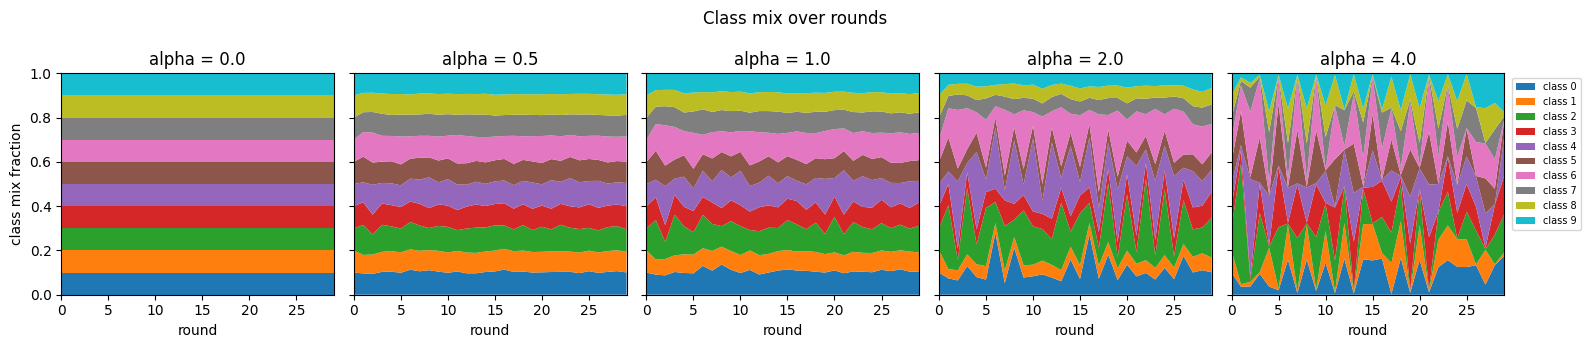

In [7]:
# Class mix over rounds -- one stacked-area panel per alpha in PLOT_ALPHAS
# (clean run). Plots from `runs`. Swap runs[a][0] -> runs[a][1] inside the
# helper to see the poisoned run's mix instead.
fig = plot_class_mix_grid({a: runs[a] for a in PLOT_ALPHAS})
save_figure(fig, f"class_mix_grid_eps{POISON_RATE}")

## Sweep: ASR & accuracy vs alpha

The full sweep over every alpha in `ALPHAS`, from `summary_rows`.

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_vs_alpha_eps0.02_20260715_130910.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_vs_alpha_eps0.02_20260715_130910.png')

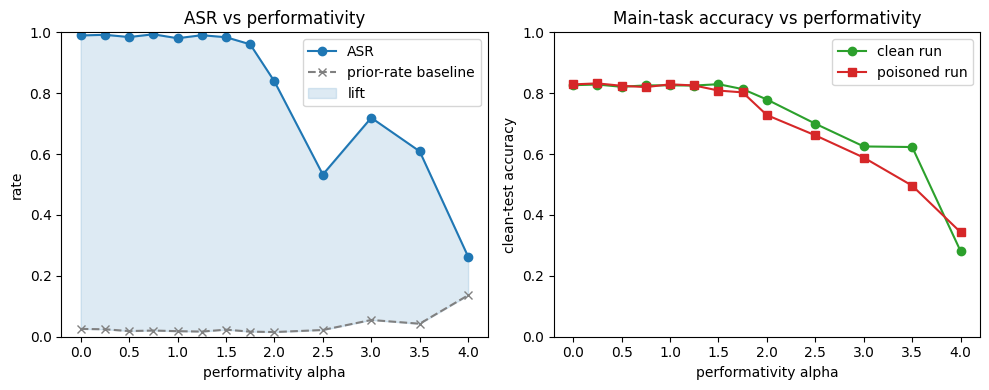

In [8]:
fig = plot_asr_vs_alpha(summary_rows)
save_figure(fig, f"asr_vs_alpha_eps{POISON_RATE}")